# Análisis de sentimientos con Naive Bayes

En este proyecto se construye un clasificador de reseñas de Google Play. La variable objetivo es `polarity`, donde `0` representa una reseña negativa y `1` una reseña positiva.

El flujo sigue la estructura solicitada por 4Geeks:

- Cargar y revisar el conjunto de datos.
- Limpiar el texto y eliminar `package_name`.
- Vectorizar las reseñas con `CountVectorizer`.
- Comparar `GaussianNB`, `MultinomialNB` y `BernoulliNB`.
- Optimizar el mejor Naive Bayes y probar Random Forest.
- Explorar otros modelos estudiados para intentar superar el resultado.
- Guardar el modelo final en la carpeta `models/`.

## Paso 1: Carga del conjunto de datos

In [1]:
%matplotlib inline

from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_colwidth", 120)

ROOT_DIR = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
DATA_URL = "https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv"
RAW_DATA_PATH = ROOT_DIR / "data" / "raw" / "playstore_reviews.csv"
PROCESSED_DATA_PATH = ROOT_DIR / "data" / "processed" / "playstore_reviews_clean.csv"
RESULTS_PATH = ROOT_DIR / "data" / "processed" / "model_results.csv"
BEST_MODEL_PATH = ROOT_DIR / "models" / "sentiment_best_model.pkl"
NB_MODEL_PATH = ROOT_DIR / "models" / "sentiment_multinomial_nb.pkl"
RF_MODEL_PATH = ROOT_DIR / "models" / "sentiment_random_forest.pkl"

RAW_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
BEST_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

if RAW_DATA_PATH.exists():
    df = pd.read_csv(RAW_DATA_PATH)
else:
    df = pd.read_csv(DATA_URL)
    df.to_csv(RAW_DATA_PATH, index=False)

print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
display(df.head())

Filas: 891 | Columnas: 3


,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offline. i mean for some people like me it's a big pressure to be seen onli...,0
1,com.facebook.katana,"messenger issues ever since the last update, initial received messages don't get pushed to the messenger app and yo...",0
2,com.facebook.katana,profile any time my wife or anybody has more than one post and i view them it would take me to there profile so tha...,0
3,com.facebook.katana,the new features suck for those of us who don't have a working back button can you guys make the videos able to be ...,0
4,com.facebook.katana,forced reload on uploading pic on replying comment last night i tried to reply a comment by uploading a photo from ...,0


El dataset contiene el nombre del paquete de la app, la reseña y la polaridad. Para predecir sentimiento usaremos el texto de la reseña, no el nombre de la aplicación.

## Paso 2: Estudio de variables y limpieza del texto

In [2]:
summary = pd.DataFrame({
    "tipo": df.dtypes,
    "nulos": df.isna().sum(),
    "valores_unicos": df.nunique()
})
display(summary)

print(f"Duplicados exactos: {df.duplicated().sum()}")
display(df["polarity"].value_counts().rename("conteo").to_frame())

,tipo,nulos,valores_unicos
package_name,object,0,23
review,object,0,891
polarity,int64,0,2


Duplicados exactos: 0


,conteo
polarity,
0,584
1,307


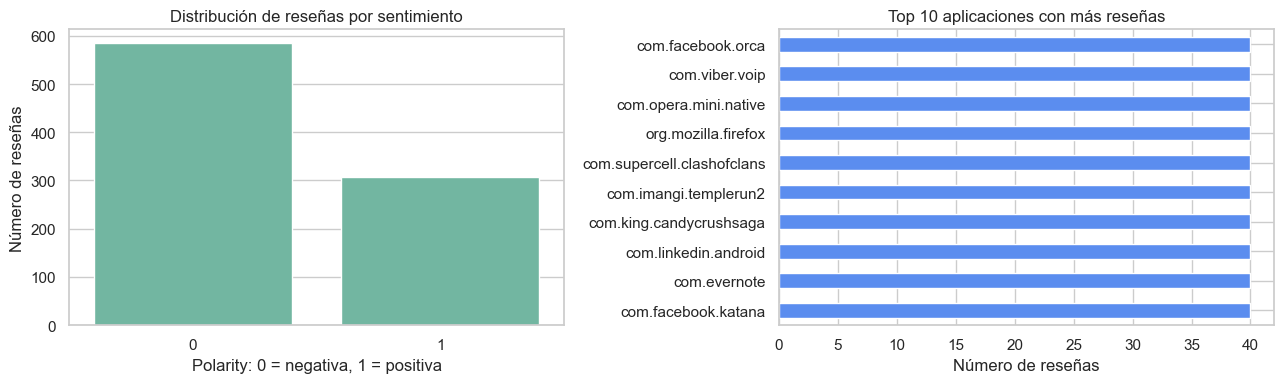

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=df, x="polarity", ax=axes[0])
axes[0].set_title("Distribución de reseñas por sentimiento")
axes[0].set_xlabel("Polarity: 0 = negativa, 1 = positiva")
axes[0].set_ylabel("Número de reseñas")

top_apps = df["package_name"].value_counts().head(10).sort_values()
top_apps.plot(kind="barh", ax=axes[1], color="#5B8DEF")
axes[1].set_title("Top 10 aplicaciones con más reseñas")
axes[1].set_xlabel("Número de reseñas")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

Aunque revisamos `package_name` para entender el dataset, la eliminamos porque el objetivo es clasificar el sentimiento a partir del contenido de `review`. Mantener el nombre de la app podría introducir ruido y sesgo hacia aplicaciones concretas.

In [4]:
clean_df = df.copy()
clean_df = clean_df.drop(columns=["package_name"])
clean_df = clean_df.dropna(subset=["review", "polarity"])
clean_df["review"] = clean_df["review"].astype(str).str.strip().str.lower()
clean_df = clean_df[clean_df["review"].str.len() > 0]
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

clean_df["review_length"] = clean_df["review"].str.len()
clean_df["word_count"] = clean_df["review"].str.split().str.len()

clean_df.to_csv(PROCESSED_DATA_PATH, index=False)

print(f"Dataset limpio: {clean_df.shape[0]} filas y {clean_df.shape[1]} columnas")
display(clean_df.head())

Dataset limpio: 890 filas y 4 columnas


,review,polarity,review_length,word_count
0,privacy at least put some option appear offline. i mean for some people like me it's a big pressure to be seen onlin...,0,385,77
1,"messenger issues ever since the last update, initial received messages don't get pushed to the messenger app and you...",0,456,79
2,profile any time my wife or anybody has more than one post and i view them it would take me to there profile so that...,0,377,78
3,the new features suck for those of us who don't have a working back button can you guys make the videos able to be s...,0,192,41
4,forced reload on uploading pic on replying comment last night i tried to reply a comment by uploading a photo from m...,0,465,89


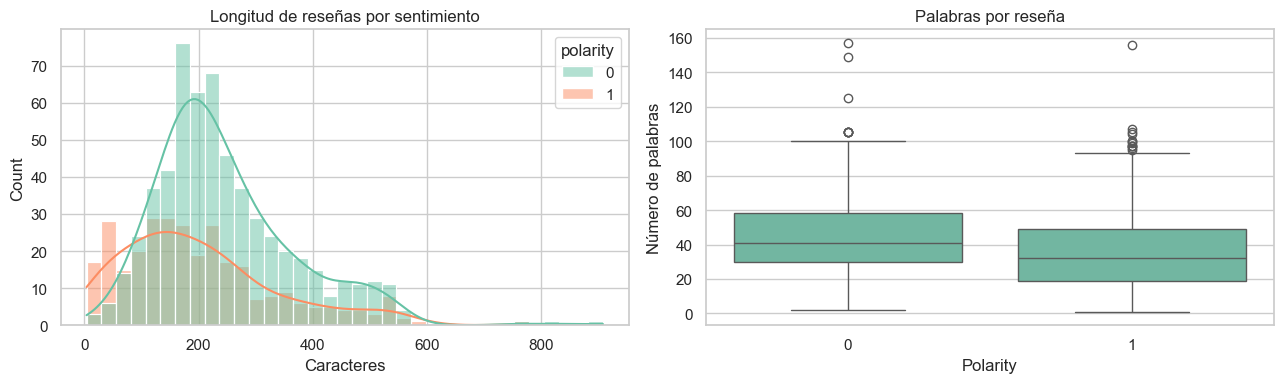

review_length                                                    \
                 count    mean     std   min    25%    50%    75%    max   
polarity                                                                   
0                583.0  246.54  122.62  11.0  163.5  219.0  302.5  908.0   
1                307.0  200.35  137.65   4.0  104.5  173.0  265.0  778.0   

         word_count                                              
              count   mean    std  min   25%   50%   75%    max  
polarity                                                         
0             583.0  45.78  22.57  2.0  30.0  41.0  58.0  157.0  
1             307.0  36.22  24.97  1.0  19.0  32.0  49.0  156.0

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=clean_df, x="review_length", hue="polarity", bins=35, kde=True, ax=axes[0])
axes[0].set_title("Longitud de reseñas por sentimiento")
axes[0].set_xlabel("Caracteres")

sns.boxplot(data=clean_df, x="polarity", y="word_count", ax=axes[1])
axes[1].set_title("Palabras por reseña")
axes[1].set_xlabel("Polarity")
axes[1].set_ylabel("Número de palabras")

plt.tight_layout()
plt.show()

display(clean_df.groupby("polarity")[["review_length", "word_count"]].describe().round(2))

Para interpretar mejor qué está aprendiendo el vectorizador, se muestran las palabras más frecuentes en reseñas negativas y positivas después de aplicar stop words en inglés.

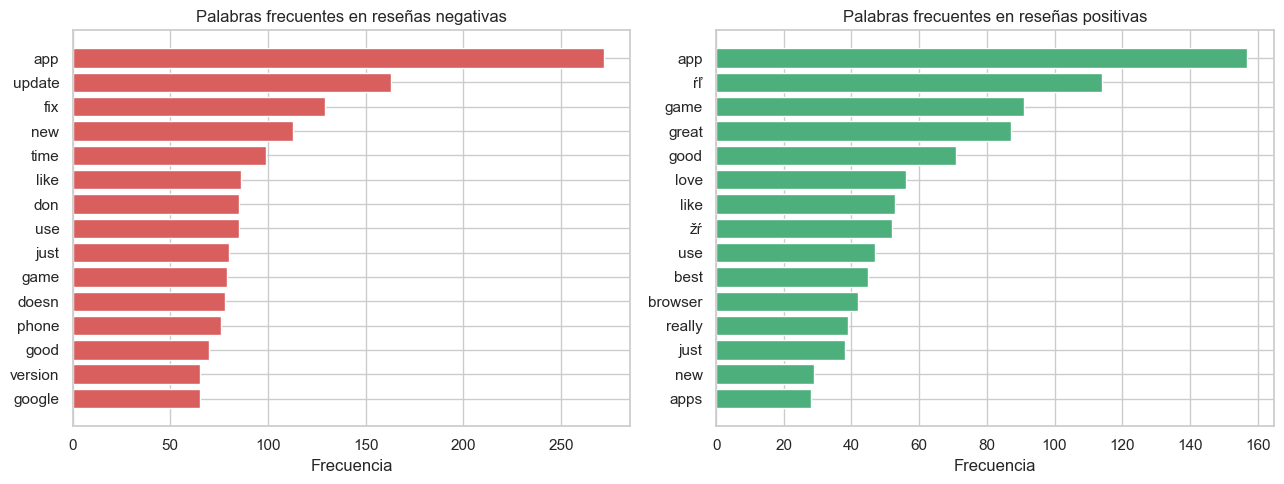

In [6]:
def top_words_by_class(data, target_value, top_n=15):
    vectorizer = CountVectorizer(stop_words="english")
    matrix = vectorizer.fit_transform(data.loc[data["polarity"] == target_value, "review"])
    counts = matrix.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()
    return (
        pd.DataFrame({"word": words, "count": counts})
        .sort_values("count", ascending=False)
        .head(top_n)
        .sort_values("count")
    )

negative_words = top_words_by_class(clean_df, 0)
positive_words = top_words_by_class(clean_df, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(negative_words["word"], negative_words["count"], color="#D95F5F")
axes[0].set_title("Palabras frecuentes en reseñas negativas")
axes[0].set_xlabel("Frecuencia")

axes[1].barh(positive_words["word"], positive_words["count"], color="#4DAF7C")
axes[1].set_title("Palabras frecuentes en reseñas positivas")
axes[1].set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()

## División train/test y vectorización

In [7]:
X = clean_df["review"]
y = clean_df["polarity"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

vec_model = CountVectorizer(stop_words="english")
X_train = vec_model.fit_transform(X_train_text)
X_test = vec_model.transform(X_test_text)

print(f"Train: {X_train.shape[0]} reseñas | Test: {X_test.shape[0]} reseñas")
print(f"Número de palabras/features: {X_train.shape[1]}")

Train: 712 reseñas | Test: 178 reseñas
Número de palabras/features: 3280


`CountVectorizer` convierte cada reseña en una matriz de recuento de palabras. Esto encaja especialmente bien con `MultinomialNB`, porque ese modelo trabaja con frecuencias o conteos discretos.

## Paso 3: Construcción y comparación de Naive Bayes

In [8]:
def get_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def evaluate_model(name, model, x_train, x_test):
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)
    return {"model": name, **get_metrics(y_test, predictions)}, predictions


nb_models = {
    "GaussianNB": GaussianNB(),
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
}

nb_results = []
nb_predictions = {}

for name, model in nb_models.items():
    if name == "GaussianNB":
        result, predictions = evaluate_model(name, model, X_train.toarray(), X_test.toarray())
    else:
        result, predictions = evaluate_model(name, model, X_train, X_test)

    nb_results.append(result)
    nb_predictions[name] = predictions

nb_results_df = pd.DataFrame(nb_results).sort_values("f1", ascending=False)
display(nb_results_df.round(4))

,model,accuracy,precision,recall,f1
1,MultinomialNB,0.8146,0.8043,0.6066,0.6916
0,GaussianNB,0.7809,0.6897,0.6557,0.6723
2,BernoulliNB,0.7921,0.8750,0.4590,0.6022


De las tres implementaciones, `MultinomialNB` es la opción más coherente para este problema porque las variables de entrada son recuentos de palabras. `GaussianNB` supone variables continuas con distribución normal, y `BernoulliNB` se centra más en presencia/ausencia binaria de términos.

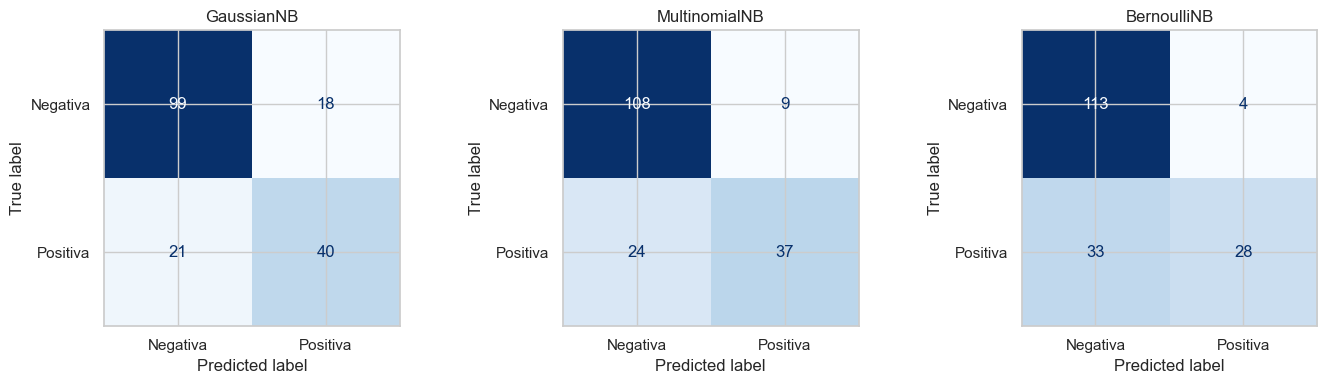

              precision    recall  f1-score   support

    Negativa       0.82      0.92      0.87       117
    Positiva       0.80      0.61      0.69        61

    accuracy                           0.81       178
   macro avg       0.81      0.76      0.78       178
weighted avg       0.81      0.81      0.81       178



In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, predictions) in zip(axes, nb_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=["Negativa", "Positiva"],
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

print(classification_report(y_test, nb_predictions["MultinomialNB"], target_names=["Negativa", "Positiva"]))

## Paso 4: Optimización y comparación con Random Forest

In [10]:
optimized_nb = GridSearchCV(
    Pipeline([
        ("vectorizer", CountVectorizer(stop_words="english")),
        ("model", MultinomialNB()),
    ]),
    param_grid={
        "vectorizer__ngram_range": [(1, 1), (1, 2)],
        "model__alpha": [0.1, 0.5, 1.0, 2.0],
    },
    scoring="f1",
    cv=5,
    n_jobs=-1,
)

optimized_nb.fit(X_train_text, y_train)
optimized_nb_predictions = optimized_nb.predict(X_test_text)

print("Mejores parámetros MultinomialNB:")
display(optimized_nb.best_params_)
display(pd.DataFrame([{"model": "Optimized MultinomialNB", **get_metrics(y_test, optimized_nb_predictions)}]).round(4))

Mejores parámetros MultinomialNB:


{'model__alpha': 0.5, 'vectorizer__ngram_range': (1, 1)}

,model,accuracy,precision,recall,f1
0,Optimized MultinomialNB,0.8371,0.82,0.6721,0.7387


In [11]:
random_forest = GridSearchCV(
    Pipeline([
        ("vectorizer", CountVectorizer(stop_words="english")),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")),
    ]),
    param_grid={
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 30],
        "model__min_samples_leaf": [1, 2],
    },
    scoring="f1",
    cv=3,
    n_jobs=-1,
)

random_forest.fit(X_train_text, y_train)
rf_predictions = random_forest.predict(X_test_text)

print("Mejores parámetros Random Forest:")
display(random_forest.best_params_)
display(pd.DataFrame([{"model": "Optimized RandomForest", **get_metrics(y_test, rf_predictions)}]).round(4))

Mejores parámetros Random Forest:


{'model__max_depth': 30,
 'model__min_samples_leaf': 1,
 'model__n_estimators': 100}

,model,accuracy,precision,recall,f1
0,Optimized RandomForest,0.8202,0.7377,0.7377,0.7377


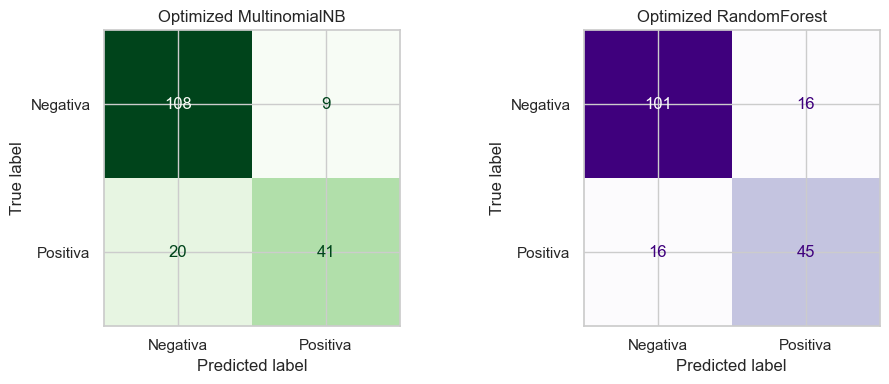

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    optimized_nb_predictions,
    display_labels=["Negativa", "Positiva"],
    cmap="Greens",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Optimized MultinomialNB")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    display_labels=["Negativa", "Positiva"],
    cmap="Purples",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title("Optimized RandomForest")

plt.tight_layout()
plt.show()

Random Forest puede capturar relaciones no lineales entre palabras, pero con texto vectorizado suele no ser tan competitivo como modelos lineales o Naive Bayes. Aun así, se prueba porque forma parte de los modelos estudiados y sirve como comparación.

## Paso 5: Guarda el modelo

Después de comparar Naive Bayes y Random Forest, se guardan los modelos optimizados en `models/`. Más adelante, tras probar alternativas, también se guardará el mejor modelo global.

In [13]:
with NB_MODEL_PATH.open("wb") as model_file:
    pickle.dump(optimized_nb.best_estimator_, model_file)

with RF_MODEL_PATH.open("wb") as model_file:
    pickle.dump(random_forest.best_estimator_, model_file)

print(f"Naive Bayes optimizado guardado en: {NB_MODEL_PATH}")
print(f"Random Forest optimizado guardado en: {RF_MODEL_PATH}")

Naive Bayes optimizado guardado en: /Users/dragcessa/Desktop/Dragcessa1998-Proyecto-Naive-Bayes-main/models/sentiment_multinomial_nb.pkl
Random Forest optimizado guardado en: /Users/dragcessa/Desktop/Dragcessa1998-Proyecto-Naive-Bayes-main/models/sentiment_random_forest.pkl


## Paso 6: Otras alternativas estudiadas

In [14]:
alternative_models = {
    "LogisticRegression TF-IDF": Pipeline([
        ("vectorizer", TfidfVectorizer(stop_words="english", ngram_range=(1, 2))),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                solver="liblinear",
                random_state=42,
                class_weight="balanced",
            ),
        ),
    ]),
    "LinearSVC TF-IDF": Pipeline([
        ("vectorizer", TfidfVectorizer(stop_words="english", ngram_range=(1, 2))),
        ("model", LinearSVC(random_state=42, class_weight="balanced")),
    ]),
}

alternative_results = []
fitted_alternatives = {}

for name, model in alternative_models.items():
    model.fit(X_train_text, y_train)
    fitted_alternatives[name] = model
    predictions = model.predict(X_test_text)
    alternative_results.append({"model": name, **get_metrics(y_test, predictions)})

all_results = pd.concat(
    [
        nb_results_df,
        pd.DataFrame([{"model": "Optimized MultinomialNB", **get_metrics(y_test, optimized_nb_predictions)}]),
        pd.DataFrame([{"model": "Optimized RandomForest", **get_metrics(y_test, rf_predictions)}]),
        pd.DataFrame(alternative_results),
    ],
    ignore_index=True,
).sort_values("f1", ascending=False)

all_results.to_csv(RESULTS_PATH, index=False)
display(all_results.round(4))

,model,accuracy,precision,recall,f1
5,LogisticRegression TF-IDF,0.8539,0.8070,0.7541,0.7797
6,LinearSVC TF-IDF,0.8427,0.8000,0.7213,0.7586
3,Optimized MultinomialNB,0.8371,0.8200,0.6721,0.7387
4,Optimized RandomForest,0.8202,0.7377,0.7377,0.7377
0,MultinomialNB,0.8146,0.8043,0.6066,0.6916
1,GaussianNB,0.7809,0.6897,0.6557,0.6723
2,BernoulliNB,0.7921,0.8750,0.4590,0.6022


Además de Naive Bayes, modelos lineales como `LogisticRegression` y `LinearSVC` son buenas alternativas para clasificación de texto. Con `TF-IDF`, estos modelos ponderan mejor las palabras que diferencian una clase de otra y reducen el peso de términos muy frecuentes.

## Guardado final del mejor modelo global

In [15]:
candidate_models = {
    "Optimized MultinomialNB": optimized_nb.best_estimator_,
    "Optimized RandomForest": random_forest.best_estimator_,
    **fitted_alternatives,
}

best_model_name = all_results.iloc[0]["model"]
best_model = candidate_models.get(best_model_name, optimized_nb.best_estimator_)

with BEST_MODEL_PATH.open("wb") as model_file:
    pickle.dump(best_model, model_file)

with NB_MODEL_PATH.open("wb") as model_file:
    pickle.dump(optimized_nb.best_estimator_, model_file)

with RF_MODEL_PATH.open("wb") as model_file:
    pickle.dump(random_forest.best_estimator_, model_file)

print(f"Mejor modelo global: {best_model_name}")
print(f"Modelo final guardado en: {BEST_MODEL_PATH}")
print(f"Naive Bayes optimizado guardado en: {NB_MODEL_PATH}")
print(f"Random Forest optimizado guardado en: {RF_MODEL_PATH}")

Mejor modelo global: LogisticRegression TF-IDF
Modelo final guardado en: /Users/dragcessa/Desktop/Dragcessa1998-Proyecto-Naive-Bayes-main/models/sentiment_best_model.pkl
Naive Bayes optimizado guardado en: /Users/dragcessa/Desktop/Dragcessa1998-Proyecto-Naive-Bayes-main/models/sentiment_multinomial_nb.pkl
Random Forest optimizado guardado en: /Users/dragcessa/Desktop/Dragcessa1998-Proyecto-Naive-Bayes-main/models/sentiment_random_forest.pkl


In [16]:
sample_reviews = pd.Series([
    "this app is amazing and very easy to use",
    "terrible update, it crashes all the time",
    "good design but the ads are annoying",
])

sample_predictions = best_model.predict(sample_reviews)
pd.DataFrame({
    "review": sample_reviews,
    "prediction": sample_predictions,
    "sentiment": ["positiva" if value == 1 else "negativa" for value in sample_predictions],
})

,review,prediction,sentiment
0,this app is amazing and very easy to use,1,positiva
1,"terrible update, it crashes all the time",0,negativa
2,good design but the ads are annoying,1,positiva


## Conclusiones

- `MultinomialNB` es el Naive Bayes más adecuado porque el texto fue transformado en recuentos de palabras.
- `GaussianNB` no es la mejor opción para este caso porque las features no son variables continuas normales.
- `BernoulliNB` funciona, pero pierde información al tratar el texto como presencia/ausencia de palabras.
- El Random Forest optimizado se probó como mejora posible, aunque en este dataset no supera al mejor modelo lineal.
- La alternativa con `LogisticRegression` y `TF-IDF` logra el mejor resultado global, por lo que se guarda como modelo final.
- También se guarda el `MultinomialNB` optimizado para conservar el mejor modelo Naive Bayes del proyecto.